# UniBEV feature Visualizer
For this to work, you need to have the `visdata.pt` of each scene / lidar file. The first visualizer is written to compare features within one detector between the modalities. But before we do anything, we need to load in the right packages.

import torch
import os
import os.path as osp
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import json
import pprint

from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval

from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
os.chdir('/home/mingdayang/mmdetection3d/')

In [1]:
import torch
import os
import os.path as osp
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import json
import pprint

from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval

from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
os.chdir('/home/mingdayang/mmdetection3d/')

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Select a file / scene to work on
Since we already ran inference on the baseline model `unibev_val_LC_full_mini_nuscenes' we will select that. We separate the variables so it is easy to select between the lidar files (the detections are grouped by the LIDAR_TOP file).

`vis_data.pt` is the features of the corresponding scene.

`lidar_folder` is the folder/scenewe are selecting within the outpute of the model we ran the inference on

`model_path_output` is the folder containing all the lidar_folder scenes

In [2]:
feature_file = "vis_data.pt" # the file containing the features to visualize

viable_lidar_folders = ["n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151603547590",
"n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607548824",
"n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607548824",
"n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607548824",
"n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984245447134",
"n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984252446890"]

lidar_folder = viable_lidar_folders[-3] # the folder containing the features to visualize
model_path_output = "/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/" # the path to the model output features

path_unibev_LC_mini = os.path.join(model_path_output, lidar_folder, feature_file)

if os.path.exists(path_unibev_LC_mini):
    print("File path exists:", path_unibev_LC_mini)
else: 
    print("File path does not exist, check the path again.", path_unibev_LC_mini)

features_unibev_LC_mini = torch.load(path_unibev_LC_mini)

File path exists: /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607548824/vis_data.pt


If you also want to compare the feature maps to the corresponding detections, then that is also possible. Then we need the json file with the corresponding detections.
`json_file` is the file containing the detections in `results_nusc.json`
`json_folder` is the folder containing metrics and the bounding boxes. 
`json_unibev_LC_mini` is the full path pointing to the json file.

In [3]:
json_file = "results_nusc.json" # the json file containing the detection results
json_folder = "pts_bbox"
json_unibev_LC_mini = os.path.join(model_path_output, json_folder, json_file)

if os.path.exists(json_unibev_LC_mini):
    print("JSON file path exists:", json_unibev_LC_mini)
else: 
    print("JSON file path does not exist, check the path again.", json_unibev_LC_mini)

JSON file path exists: /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/pts_bbox/results_nusc.json


Then using the nuScenes code, we can generate the Birds Eye View Pointcloud with GT, FP and FN detections. We will load the code needed for that now.

In [12]:
data_root = 'data/nuscenes/'
nusc = NuScenes(version='v1.0-mini', dataroot=data_root, verbose=True)
eval_set = 'mini_val'
eval_detect_configs = config_factory('detection_cvpr_2019')


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.435 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


The following code finds the corresponding scene that fits with the lidar_folder name. This is done so we can use the nuScenes code to generate the image with ground truth and top view point cloud.

In [5]:
def find_sample_token(lidar_folder):
    print(lidar_folder.split('__'))
    timestamp_str = lidar_folder.split('__')[-1]
    print(timestamp_str)
    target_timestamp = int(timestamp_str)
    print(target_timestamp)

    # Initialize variables to track the closest sample
    closest_sample_token = None
    closest_time_diff = float('inf')

    # Iterate through all scenes
    for scene in nusc.scene:
        # Start from the first sample of the scene
        current_sample_token = scene['first_sample_token']

        while current_sample_token:
            # Retrieve the sample
            sample = nusc.get('sample', current_sample_token)

            # Calculate the time difference between the sample and the target timestamp
            time_diff = abs(sample['timestamp'] - target_timestamp)

            # Check for an exact match
            if sample['timestamp'] == target_timestamp:
                closest_sample_token = current_sample_token
                closest_time_diff = 0
                break

            # Update closest sample if this sample is closer
            if time_diff < closest_time_diff:
                closest_sample_token = current_sample_token
                closest_time_diff = time_diff

            # Move to the next sample in the scene
            current_sample_token = sample['next']

        # Break if we found an exact match
        if closest_time_diff == 0:
            break

    # Output the closest sample token and time difference
    if closest_sample_token:
        print(f"Closest sample token: {closest_sample_token}")
        print(f"Time difference (microseconds): {closest_time_diff}")
    else:
        print("No matching sample token found.")

    sample_token=closest_sample_token
    return sample_token

In [6]:
sample_token=find_sample_token(lidar_folder)

['n008-2018-08-01-15-16-36-0400', 'LIDAR_TOP', '1533151607548824']
1533151607548824
1533151607548824
Closest sample token: fa65a298c01f44e7a182bbf9e5fe3697
Time difference (microseconds): 0


In [7]:
results_output_dir_unibev_LC_mini_nuscenes = f'/tmp/nuscenes_vis/qualitative/unibev_val_LC_full_mini_nuscenes'

nusc_eval_unibev_LC_mini_nuscenes = DetectionEvalVis(
    nusc = nusc,
    config=eval_detect_configs,
    result_path=json_unibev_LC_mini,
    eval_set=eval_set,
    output_dir=results_output_dir_unibev_LC_mini_nuscenes,
    verbose=True)

Initializing nuScenes detection evaluation
Loaded results from /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/pts_bbox/results_nusc.json. Found detections for 81 samples.
Loading annotations for mini_val split from nuScenes version: v1.0-mini


100%|██████████| 81/81 [00:00<00:00, 283.27it/s]


Loaded ground truth annotations for 81 samples.
Filtering predictions
=> Original number of boxes: 19305
=> After distance based filtering: 19302
=> After LIDAR and RADAR points based filtering: 19302
=> After bike rack filtering: 19226
Filtering ground truth annotations
=> Original number of boxes: 4441
=> After distance based filtering: 3785
=> After LIDAR and RADAR points based filtering: 3393
=> After bike rack filtering: 3393


# Feature maps
The feature maps keys are as follows for UniBEV

In [9]:
print(type(features_unibev_LC_mini))
print(features_unibev_LC_mini.keys())
print(features_unibev_LC_mini['lidar_file_name'])
print(features_unibev_LC_mini['img_bev_embed'].shape)
print(features_unibev_LC_mini['img_mlvl_feats'])

<class 'dict'>
dict_keys(['ori_img_bev_embed', 'ori_pts_bev_embed', 'feature_weights', 'channel_weights_norm', 'img_norm_weights', 'pts_norm_weights', 'fused_bev_embed', 'img_mlvl_feats', 'img_bev_embed', 'pts_mlvl_feats', 'pts_bev_embed', 'query', 'bev_queries', 'bev_pos', 'query_pos', 'reference_points', 'lidar_file_name'])
n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607548824
torch.Size([1, 40000, 256])
[tensor([[[[[ 6.9170e+00,  7.7459e+00,  8.5684e+00,  ...,  7.0691e+00,
             6.7181e+00,  4.5507e+00],
           [ 3.9067e+00,  3.2084e+00,  1.0192e+01,  ...,  2.2812e+00,
             6.6047e+00,  1.2301e+00],
           [ 6.9411e+00,  3.5482e+00,  4.1048e+00,  ...,  5.7696e+00,
             1.0601e+01,  6.6378e+00],
           ...,
           [-3.0023e+01, -2.4507e+01, -1.7719e+01,  ...,  3.1951e+00,
             2.1930e+00,  4.3641e+00],
           [-2.7596e+01, -2.1556e+01, -1.8794e+01,  ...,  2.8794e+00,
             3.8500e+00,  2.8936e+00],
           [-2.6184e+01

## Helper functions
These helper functions will help us create the feature maps and display them. Read each functions docstring to see what it does

In [14]:
def max_pool_activations(feature_tensor, key):
    """Computes the max-pooled activations for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    max_pooled_activation = torch.max(activation, dim=2)[0]  # Max pool across channels
    max_pooled_activation = max_pooled_activation.cpu().numpy()  # Convert to numpy array
    max_pooled_activation = np.flip(max_pooled_activation, axis=0)  # Flip vertically for correct orientation

    return max_pooled_activation

def mean_activations(feature_tensor, key):
    """Computes the mean activations for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    mean_activation = torch.mean(activation, dim=2)  # Calculate mean across channels
    mean_activation = mean_activation.cpu().numpy()  # Convert to numpy array
    mean_activation = np.flip(mean_activation, axis=0)  # Flip vertically for correct orientation

    return mean_activation


def channel_activations(feature_tensor, key, channel):
    """Computes the activations for a specific channel for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    channel_activation = activation[:,:,channel]  # Extract the specified channel
    channel_activation = channel_activation.cpu().numpy()  # Convert to numpy array
    channel_activation = np.flip(channel_activation, axis=0)  # Flip vertically for correct orientation

    return channel_activation

def figure_to_image(fig):
    fig.canvas.draw()  # Render the figure
    # Convert to a numpy array
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)  # Close the figure after conversion
    return image

def plot_singular_BEV_pointcloud(sample_token, nusc):
    """Plots the BEV point cloud for a given sample token."""
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    sample_fig = nusc.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True)
    sample_image = figure_to_image(sample_fig)
    ax.imshow(sample_image)
    ax.set_title(f"BEV Point Cloud for Sample Token: {sample_token}")
    ax.axis('off')
    ax.set_ylim(800, 106)
    ax.set_xlim(106, 800)
    plt.tight_layout()
    plt.close(sample_fig)
    plt.show()

def plot_singular_feature_map(feature_tensor, key, method, channel=None):
    """Plots a singular feature map based on the specified method.
    
    Args:
        feature_tensor (tensor): The feature tensor containing various feature maps.
        key (str): The key to access the desired feature map.
        method (str): The method to reduce the feature map ('channel', 'max_pool', 'mean').
        channel (int, optional): The channel index to visualize if method is 'channel

    Available methods are 'channel', 'max_pool', and 'mean'.
    """
    fig, axs = plt.subplots(1, 1, figsize=(6,6))

    activation = None

    if method == 'channel':
        activation = channel_activations(feature_tensor, key, channel)
    elif method == 'max_pool':
        activation = max_pool_activations(feature_tensor, key)
    elif method == 'mean':
        activation = mean_activations(feature_tensor, key)
    else:
        raise ValueError(f"Unknown method: {method}")

    im = axs.imshow(activation, cmap='viridis')
    axs.set_title(f"{method} from {key}")
    axs.grid()
    fig.colorbar(im, ax=axs, orientation='vertical', shrink=0.7)
    plt.tight_layout()
    plt.show()

def plot_camera_against_lidar_feature_map(feature_tensor,
                                          method,
                                          channel=None,
                                          share_colorbar=True):
    """Plots camera BEV feature map against LiDAR BEV feature map."""
    img_key = 'img_bev_embed'
    pts_key = 'pts_bev_embed'

    fig, axs = plt.subplots(1, 2, figsize=(12,6))

    img_activation, pts_activation = None, None

    if method == 'channel':
        img_activation = channel_activations(feature_tensor, img_key, channel)
        pts_activation = channel_activations(feature_tensor, pts_key, channel)
    elif method == 'max_pool':
        img_activation = max_pool_activations(feature_tensor, img_key)
        pts_activation = max_pool_activations(feature_tensor, pts_key)
    elif method == 'mean':
        img_activation = mean_activations(feature_tensor, img_key)
        pts_activation = mean_activations(feature_tensor, pts_key)
    else:
        raise ValueError(f"Unknown method: {method}")

    # axs[0].imshow(img_activation, cmap='viridis')
    channel_str = f" {channel}" if method == 'channel' else ""
    axs[0].set_title(f"({img_key}) Feature Map {method} {channel_str}")
    axs[0].grid()

    # axs[1].imshow(pts_activation, cmap='viridis')
    axs[1].set_title(f"({pts_key}) Feature Map {method} {channel_str}")
    axs[1].grid()
    
    # Ensure both plots share the same color scale
    if share_colorbar:
        vmin = min(np.min(img_activation), np.min(pts_activation))
        vmax = max(np.max(img_activation), np.max(pts_activation))
        im0 = axs[0].imshow(img_activation, cmap='viridis', vmin=vmin, vmax=vmax)
        im1 = axs[1].imshow(pts_activation, cmap='viridis', vmin=vmin, vmax=vmax)
        # Add a single colorbar for both plots
        # Place the colorbar next to the plots on the right side
        pos_right = axs[1].get_position()  # Position of the right plot
        cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])  # Adjust to the height of the subplot
        fig.colorbar(im1, cax=cbar_ax)
    
        plt.tight_layout(rect=[0, 0, 0.9, 1])
    else:
        axs[0].imshow(img_activation, cmap='viridis')
        axs[1].imshow(pts_activation, cmap='viridis')
        plt.tight_layout()
    plt.show()








def plot_feature_map(model, key, method='channel', beams=8, channel=1):
    return

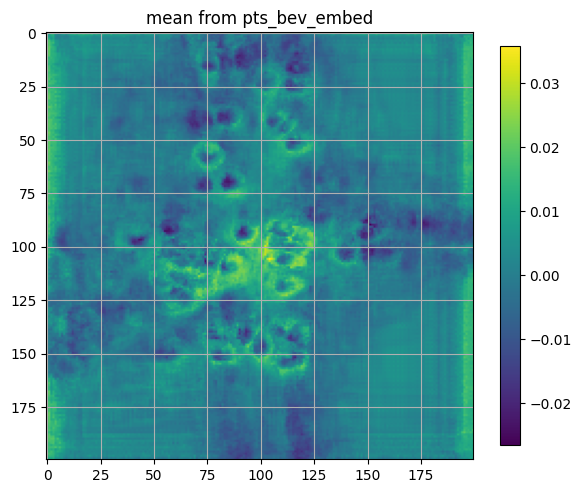

In [15]:
key = 'pts_bev_embed'
plot_singular_feature_map(features_unibev_LC_mini, key, method='mean', channel=None)

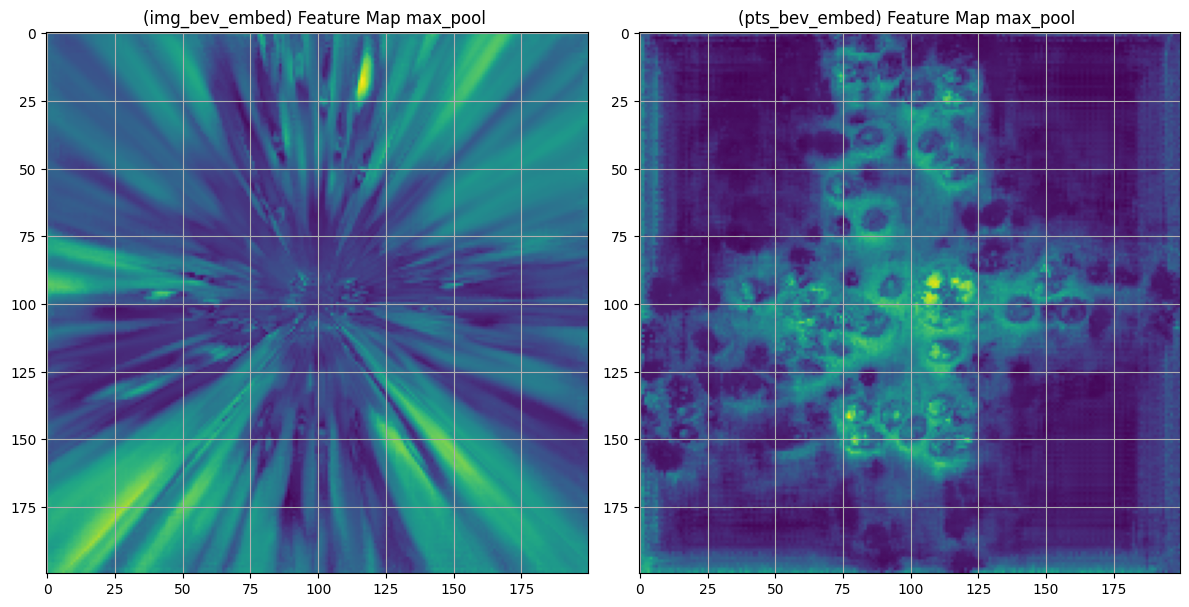

In [11]:
plot_camera_against_lidar_feature_map(features_unibev_LC_mini, method='max_pool', channel=1, share_colorbar=False)

Rendering sample token fa65a298c01f44e7a182bbf9e5fe3697


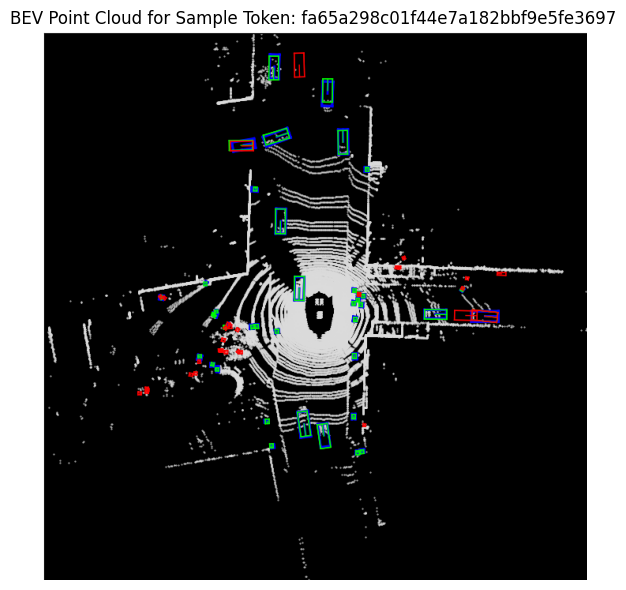

In [148]:
plot_singular_BEV_pointcloud(sample_token, nusc_eval_unibev_LC_mini_nuscenes)